In [1]:
!pip install pandas

In [2]:
pip install numpy matplotlib seaborn scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.


                                                 Importation des librairies

In [3]:
#Importation des bibliothèques
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline    
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from matplotlib.colors import ListedColormap
from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score
from sklearn import metrics

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aosow\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aosow\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                                         Chargement des données

In [4]:
import os
dossier = r"C:\Users\aosow\Documents\IA_SPAM"
print(os.listdir(dossier))

['Guineacona_Spam_Data_Alpha.xlsx', 'IA_Spam.ipynb']


In [5]:
# On utilise read_excel car l'extension est .xlsx
data = pd.read_excel(r"C:\Users\aosow\Documents\IA_SPAM\Guineacona_Spam_Data_Alpha.xlsx")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10163 entries, 0 to 10162
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    10163 non-null  object
 1   Message  10163 non-null  object
dtypes: object(2)
memory usage: 158.9+ KB


In [6]:
data.rename(columns = {"label":"Target", "Message":"Text"}, inplace = True)
data.head()

,Target,Text
0,spam,Votre compte Orange money à été bloquée pour l...
1,ham,Félicitation vous avez acheté un Pass de 250 m...
2,spam,Vous avez gagner de l'argent appelez ce numéro...
3,ham,Bonjour veuillez vous rendre au siège Orange s...
4,ham,Bjr rapprocher vous de votre agence le plus pr...


                                                        Exploration des données

C:\Users\aosow\AppData\Local\Temp\ipykernel_16980\620511386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fg = sns.countplot(x=data["Target"], palette=palette_fixe)


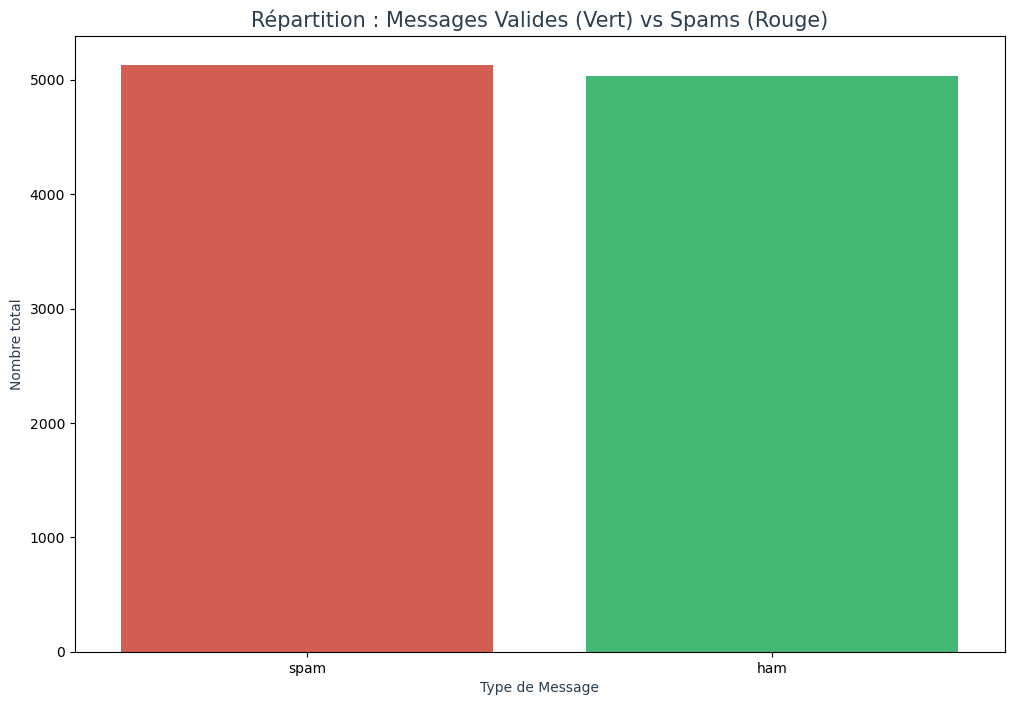

In [7]:
# on utilise un dictionnaire {} pour fixer les noms
palette_fixe = {"ham": "#2ECC71", "spam": "#E74C3C"}

plt.figure(figsize=(12,8))

# On utilise 'palette=palette_fixe'
fg = sns.countplot(x=data["Target"], palette=palette_fixe)

fg.set_title("Répartition : Messages Valides (Vert) vs Spams (Rouge)", color="#2C3E50", fontsize=15)
fg.set_xlabel("Type de Message", color="#2C3E50")
fg.set_ylabel("Nombre total", color="#2C3E50")

plt.show()

Pour l'exploration des données, nous créons les variables suivantes : 

No_of_Characters : Nombre de caractères dans le message texte.

No_of_Words : Nombre de mots dans le message texte.

No_of_sentence : Nombre de phrases dans le message texte.

In [8]:
data["No_of_Characters"] = data["Text"].apply(len)
data["No_of_Words"]=data.apply(lambda row: nltk.word_tokenize(row["Text"]), axis=1).apply(len)
data["No_of_sentence"]=data.apply(lambda row: nltk.sent_tokenize(row["Text"]), axis=1).apply(len)

data.describe().T

,count,mean,std,min,25%,50%,75%,max
No_of_Characters,10163.0,86.330217,17.808218,15.0,73.0,84.0,101.0,220.0
No_of_Words,10163.0,14.876218,2.603728,3.0,14.0,15.0,18.0,38.0
No_of_sentence,10163.0,1.291745,0.457608,1.0,1.0,1.0,2.0,4.0


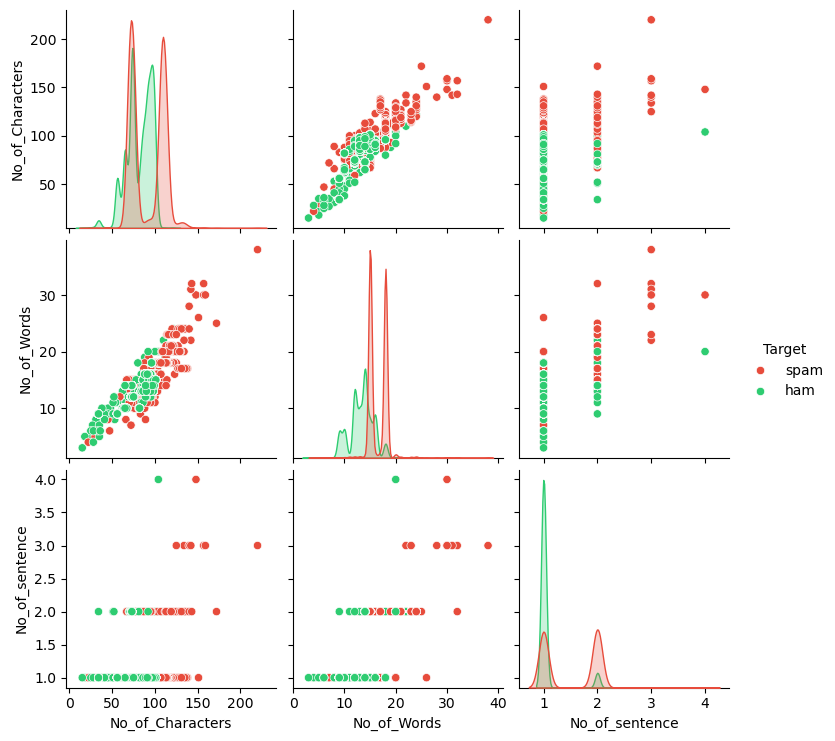

In [9]:
palette_fixe = {"ham": "#2ECC71", "spam": "#E74C3C"}

# On crée le graphique
fg = sns.pairplot(data=data, hue="Target", palette=palette_fixe)

# On affiche
plt.show()

In [10]:
# Les messages extrêmement longues risquent de fausser l'apprentissage de l'IA.
# On filtre le dataset pour ne garder que les messages avec moins de 350 caractères
# Traitement des valeurs abberantes. 
data = data[(data["No_of_Characters"]<350)]
data.shape

(10163, 5)

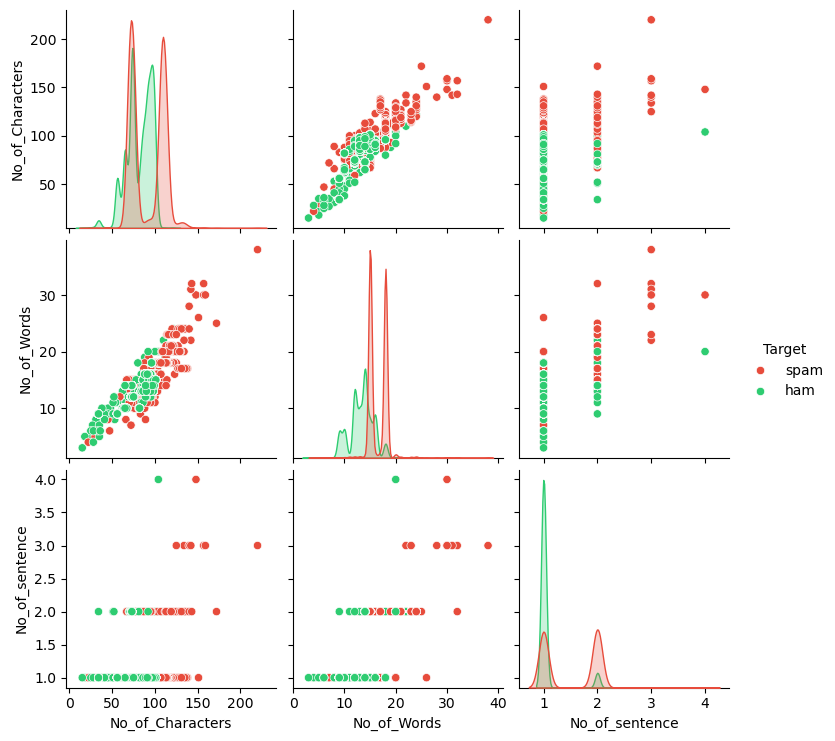

In [11]:
# On utilise un dictionnaire pour "verrouiller" les couleurs aux noms
palette_fixe = {"ham": "#2ECC71", "spam": "#E74C3C"}

# On génère le Pairplot
fg = sns.pairplot(data=data, hue="Target", palette=palette_fixe)

# On affiche le graphique
plt.show()

                           Traitement ou Nettoyage des données avec la NLP (Natural Language Processing)

In [12]:
# On télécharge les "mots vides" français
nltk.download('stopwords')
stop_words_french = set(stopwords.words('french'))

def clean_text_fr(text):
    # Tout en minuscules
    text = text.lower()
    
    # Supprimer la ponctuation et les chiffres
    # On garde les lettres avec accents (é, à, è, etc.)
    text = re.sub(r'[^a-zàâçéèêëîïôûùµÿñæœ]', ' ', text)
    
    # Séparer en mots
    words = text.split()
    
    # Supprimer les mots inutiles français (le, la, du, etc.)
    useful_words = [w for w in words if w not in stop_words_french]
    
    return " ".join(useful_words)

# On applique le nettoyage spécial français
data["Clean_Text"] = data["Text"].apply(clean_text_fr)

# Affichage du résultat
print("\033[1m\u001b[42;1m Aperçu des textes nettoyés (FR) :\033[0m", *data["Clean_Text"][:5], sep = "\n")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aosow\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


 Aperçu des textes nettoyés (FR) :
compte orange money bloquée débloquer veuillez taper code
félicitation acheté pass mo gnf
gagner argent appelez numéro recevoir argent
bonjour veuillez rendre siège orange si proche
bjr rapprocher agence plus proche


                                                         Tokenization

In [13]:
# Création d'une nouvelle colonne où chaque message est découpé en mots
data["Tokenized_Text"] = data["Clean_Text"].apply(nltk.word_tokenize)

print("\033[1m\u001b[46;1m Aperçu après Tokenisation :\033[0m")
print(data["Tokenized_Text"][:5])

 Aperçu après Tokenisation :
0    [compte, orange, money, bloquée, débloquer, ve...
1                [félicitation, acheté, pass, mo, gnf]
2    [gagner, argent, appelez, numéro, recevoir, ar...
3    [bonjour, veuillez, rendre, siège, orange, si,...
4              [bjr, rapprocher, agence, plus, proche]
Name: Tokenized_Text, dtype: object


                                  Suppressions des Stop words, les mots inutiles

In [14]:
# On charge la liste des mots inutiles en français
stop_words = set(stopwords.words('french'))

# Fonction pour filtrer les listes de mots
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# ON CRÉE LES COLONNES 
# D'abord on transforme la phrase en liste de mots
data["Tokenize_Text"] = data["Clean_Text"].apply(nltk.word_tokenize)

# ENSUITE on retire les mots inutiles
data["Nostopword_Text"] = data["Tokenize_Text"].apply(remove_stopwords)

# Affichage du résultat
print("\033[1m\u001b[42;1m Textes après suppression des mots inutiles : \033[0m")
print(data["Nostopword_Text"][:5])

 Textes après suppression des mots inutiles : 
0    [compte, orange, money, bloquée, débloquer, ve...
1                [félicitation, acheté, pass, mo, gnf]
2    [gagner, argent, appelez, numéro, recevoir, ar...
3    [bonjour, veuillez, rendre, siège, orange, si,...
4              [bjr, rapprocher, agence, plus, proche]
Name: Nostopword_Text, dtype: object


                                                              Lemmatization

In [15]:
# Ces deux lignes téléchargent les "dictionnaires" de racines de mots
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialisation du lemmatiseur
lemmatizer = WordNetLemmatizer()

# Fonction pour lemmatiser chaque mot de la liste
def lemmatize_word(text):
    # On ramène chaque mot à sa racine (v = verbe)
    lemmas = [lemmatizer.lemmatize(word, pos='v') for word in text]
    return lemmas

# Application sur la colonne sans mots inutiles
data["Lemmatized_Text"] = data["Nostopword_Text"].apply(lemmatize_word)

# Affichage du résultat final
print("\033[1m\u001b[45;1m Les 5 premiers textes après lemmatisation :\033[0m")
print(*data["Lemmatized_Text"][:5], sep="\n")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aosow\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aosow\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


 Les 5 premiers textes après lemmatisation :
['compte', 'orange', 'money', 'bloquée', 'débloquer', 'veuillez', 'taper', 'code']
['félicitation', 'acheté', 'pass', 'mo', 'gnf']
['gagner', 'argent', 'appelez', 'numéro', 'recevoir', 'argent']
['bonjour', 'veuillez', 'rendre', 'siège', 'orange', 'si', 'proche']
['bjr', 'rapprocher', 'agence', 'plus', 'proche']


                                                         La Vectorisation avec tf-idf

In [16]:
# On crée le corpus
corpus = []
for i in data["Lemmatized_Text"]:
    msg = ' '.join([row for row in i])
    corpus.append(msg)

# On affiche l'aperçu
print("\033[1m\u001b[45;1m Les 5 premières lignes du corpus :\033[0m", *corpus[:5], sep = "\n")

# On vectorise (la suite logique)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(corpus).toarray()

print(f"\n\033[1m\u001b[42;1m Taille de la matrice X : {X.shape}\033[0m")

 Les 5 premières lignes du corpus :
compte orange money bloquée débloquer veuillez taper code
félicitation acheté pass mo gnf
gagner argent appelez numéro recevoir argent
bonjour veuillez rendre siège orange si proche
bjr rapprocher agence plus proche

 Taille de la matrice X : (10163, 889)


In [17]:
# On initialise l'outil qui va calculer l'importance des mots
tfidf = TfidfVectorizer()

# On transforme le corpus (texte) en une matrice de nombres (X)
X = tfidf.fit_transform(corpus).toarray()

# On vérifie le type de données stockées dans la matrice
print(f"Type de données de la matrice X : {X.dtype}")

Type de données de la matrice X : float64


In [18]:
# On initialise l'encodeur
label_encoder = LabelEncoder()

# On transforme les mots "Ham"/"Spam" en 0 et 1
data["Target"] = label_encoder.fit_transform(data["Target"])

# On définit notre variable y pour l'entraînement
y = data["Target"]

                                                                  Entraînement du Modèle

In [19]:

# On définit la cible (y)
y = data["Target"] 

# On sépare les données (X et y) en deux groupes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Messages d'entraînement : {X_train.shape[0]}")
print(f"Messages de test : {X_test.shape[0]}")

Messages d'entraînement : 8130
Messages de test : 2033


In [20]:
# Test des classifieurs suivants
classifiers = [MultinomialNB(), 
               RandomForestClassifier(),
               KNeighborsClassifier(), 
               SVC()]

for cls in classifiers:
    cls.fit(X_train, y_train)

# Dictionnaire des pipelines et types de modèles pour faciliter la référence
pipe_dict = {0: "NaiveBayes", 1: "RandomForest", 2: "KNeighbours", 3: "SVC"}

                                                                 Construction du Modèle
Nous avons utilisés 6 modèles de classifications pour un très bon résultat :
MultinomialNB

RandomForestClassifier

KNeighborsClassifier

SVC

LogisticRegression

DecisionTreeClassifier

In [21]:
# Import des nouveaux modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Test des classifieurs (liste complétée)
classifiers = [MultinomialNB(), 
               RandomForestClassifier(),
               KNeighborsClassifier(), 
               SVC(),
               LogisticRegression(),     # Ajouté : Rapide et efficace pour le texte
               DecisionTreeClassifier()] # Ajouté : Version simple de l'arbre

for cls in classifiers:
    cls.fit(X_train, y_train)

# Dictionnaire mis à jour pour inclure les nouveaux modèles
pipe_dict = {0: "NaiveBayes", 1: "RandomForest", 2: "KNeighbours", 
             3: "SVC", 4: "LogisticRegression", 5: "DecisionTree"}

In [22]:
# Validation croisée (Cross-validation)
for i, model in enumerate(classifiers):
    # On calcule le score moyen sur 10 tests différents
    cv_score = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=10)
    print("%s: %f " % (pipe_dict[i], cv_score.mean()))

NaiveBayes: 0.996802 
RandomForest: 0.998155 
KNeighbours: 0.996187 
SVC: 0.997909 
LogisticRegression: 0.997909 
DecisionTree: 0.997663 


In [23]:
# Évaluation du modèle
# Création des listes pour les différents scores
precision = []
recall = []
f1_score = []
trainset_accuracy = []
testset_accuracy = []

for i in classifiers:
    pred_train = i.predict(X_train)
    pred_test = i.predict(X_test)
    
    # Calcul des métriques
    prec = metrics.precision_score(y_test, pred_test)
    recal = metrics.recall_score(y_test, pred_test)
    f1_s = metrics.f1_score(y_test, pred_test)
    
    # Correction ici : on utilise 'i' pour chaque modèle de la liste
    train_accuracy = i.score(X_train, y_train)
    test_accuracy = i.score(X_test, y_test)
  
    # Ajout des scores aux listes
    precision.append(prec)
    recall.append(recal)
    f1_score.append(f1_s)
    trainset_accuracy.append(train_accuracy)
    testset_accuracy.append(test_accuracy)

,Precision,Recall,F1score,Accuracy on Testset,Accuracy on Trainset
SVC,0.998090,0.999044,0.998567,0.998524,1.000000
DecisionTree,0.999041,0.996176,0.997607,0.997541,1.000000
NaiveBayes,0.998084,0.996176,0.997129,0.997049,0.999016
RandomForest,1.000000,0.994264,0.997124,0.997049,1.000000
LogisticRegression,1.000000,0.993308,0.996643,0.996557,0.998524
KNeighbours,0.994286,0.998088,0.996183,0.996065,0.997171


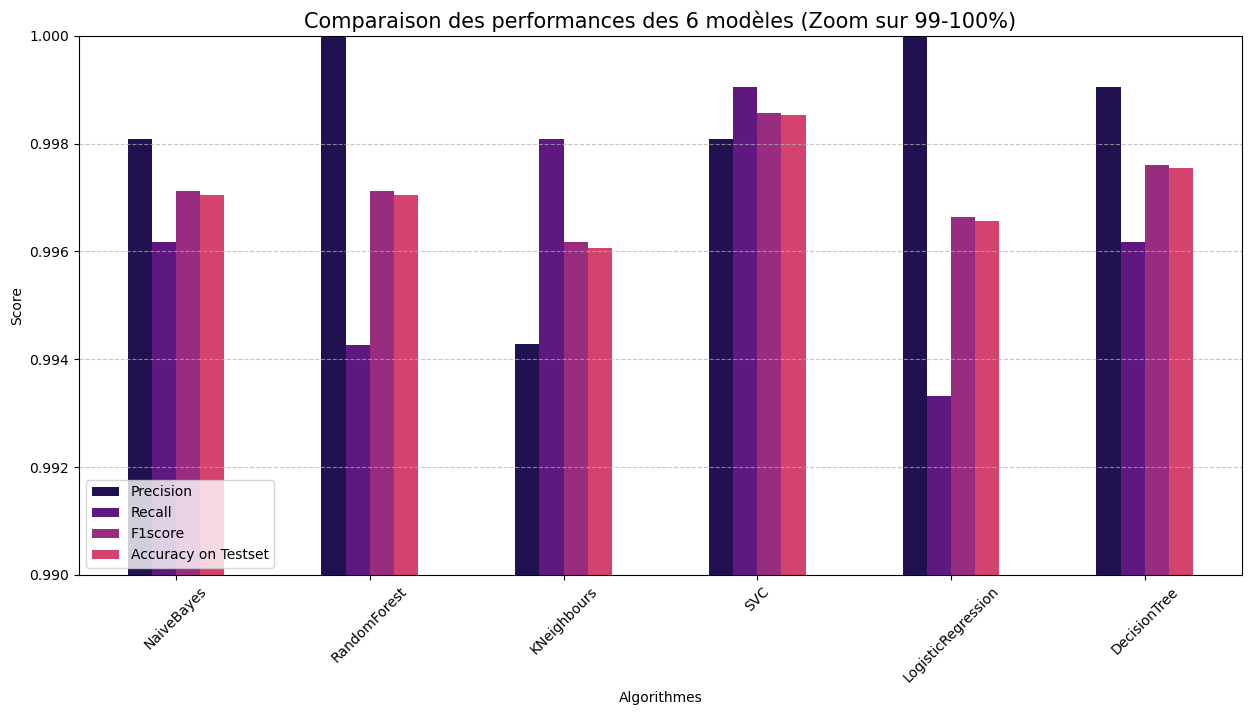

In [24]:
# Initialisation des données
data_results = {
    'Precision': precision,
    'Recall': recall,
    'F1score': f1_score,
    'Accuracy on Testset': testset_accuracy,
    'Accuracy on Trainset': trainset_accuracy
}

# Création du DataFrame
Results = pd.DataFrame(data_results, index=["NaiveBayes", "RandomForest", "KNeighbours", "SVC", "LogisticRegression", "DecisionTree"])

# Affichage du tableau stylisé
# On utilise display() pour forcer l'affichage du tableau avant le graphique
from IPython.display import display
cmap2 = ListedColormap(["#E2CCFF","#E598D8"])
display(Results.sort_values(by='F1score', ascending=False).style.background_gradient(cmap=cmap2))

# Création et affichage du graphique (juste en dessous)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("magma") # Utilisation de magma pour éviter l'erreur
ax = Results[['Precision', 'Recall', 'F1score', 'Accuracy on Testset']].plot(
    kind='bar', 
    figsize=(15, 7),
    ylim=(0.99, 1.0)
)

plt.title("Comparaison des performances des 6 modèles (Zoom sur 99-100%)", fontsize=15)
plt.ylabel("Score")
plt.xlabel("Algorithmes")
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

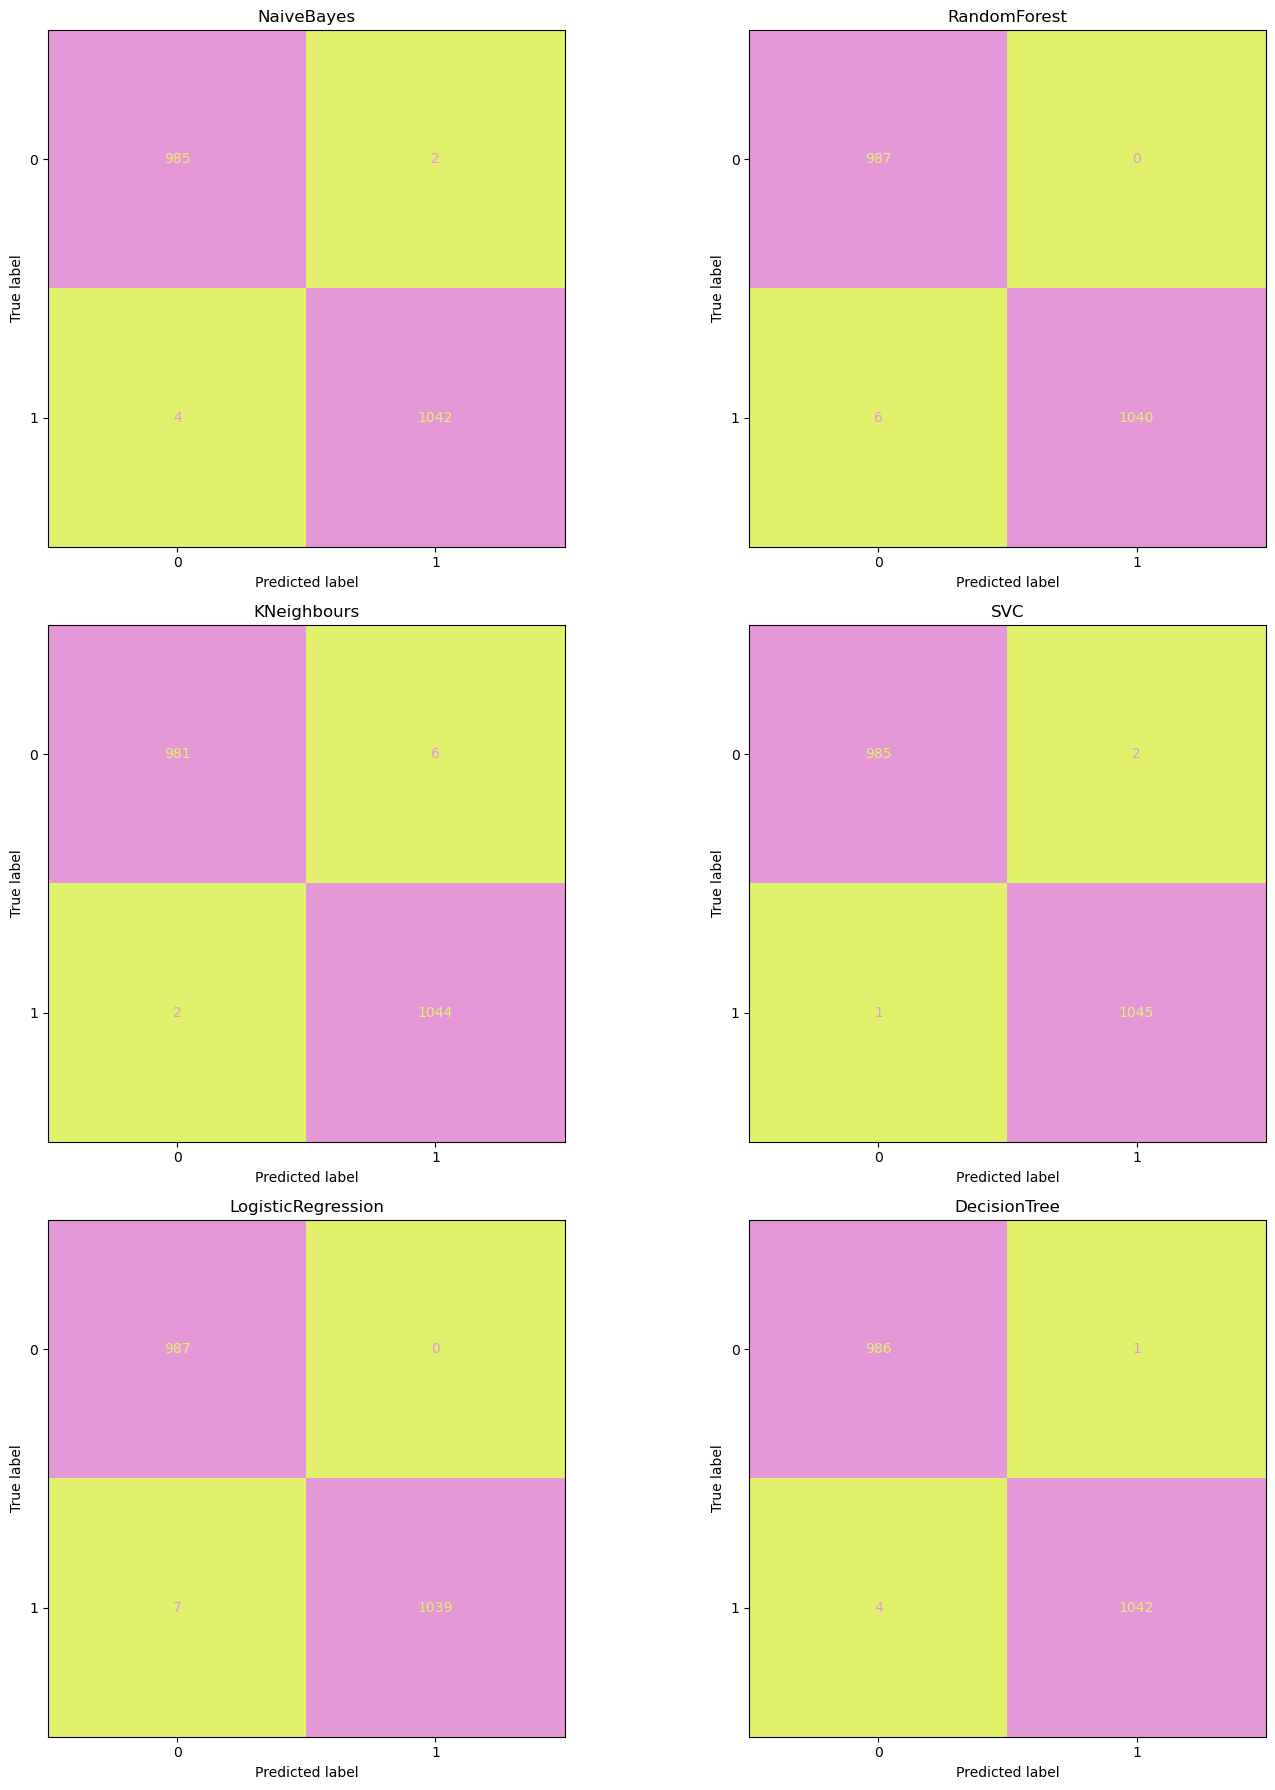

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

cmap = ListedColormap(["#E1F16B", "#E598D8"])

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, (cls, ax) in enumerate(zip(classifiers, axes)):
    ConfusionMatrixDisplay.from_estimator(
        cls, 
        X_test, 
        y_test, 
        ax=ax, 
        cmap=cmap,
        colorbar=False
    )
    ax.title.set_text(pipe_dict[i]) # Utilise le nom propre depuis ton dictionnaire

plt.tight_layout()  
plt.show()

In [26]:
import pickle
# Sauvegarde
pickle.dump(classifiers[3], open('modele_spam_final.pkl', 'wb'))
pickle.dump(tfidf, open('vectoriseur.pkl', 'wb'))

In [27]:
# Transforme le texte (utilise 'tfidf' car c'est le nom défini en [26])
sample_vec = tfidf.transform(["Salut, on se voit demain pour le café ?"])

# Conversion en array dense
sample_dense = sample_vec.toarray()

# Prédit (utilise 'classifiers[3]')
print(classifiers[3].predict(sample_dense))

[0]


In [28]:
!pip install gradio

In [29]:
import gradio as gr
import pickle

# Chargement du modèle de SPam
model = pickle.load(open('modele_spam_final.pkl', 'rb'))
tfidf = pickle.load(open('vectoriseur.pkl', 'rb'))

def detecter_spam(message):
    vec = tfidf.transform([message]).toarray()
    prediction = model.predict(vec)[0]
    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ PAS SPAM"

# Interface
interface = gr.Interface(
    fn=detecter_spam,
    inputs=gr.Textbox(placeholder="Salut, ça va", label="Message"),
    outputs=gr.Label(label="Résultat"),
    title="🛡️ Détection de Spam",
    description="Entrez un message pour savoir s'il est un spam ou non."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [30]:
!pip install flask streamlit

In [31]:
import os
print(os.path.getsize('modele_spam_final.pkl') / 1024 / 1024, "MB")
print(os.path.getsize('vectoriseur.pkl') / 1024 / 1024, "MB")

2.5314159393310547 MB
0.018228530883789062 MB
